In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
df = pd.read_csv("netflixdata.csv")

df.head()

,Column1,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,UNKNOWN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",NaN,NaN,NaN,NaN,NaN,NaN
1,s2,TV Show,Blood & Water,UNKNOWN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",NaN,NaN,NaN,NaN,NaN,NaN
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",UNKNOWN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,NaN,NaN,NaN,NaN,NaN,2676.0
3,s4,TV Show,Jailbirds New Orleans,UNKNOWN,UNKNOWN,UNKNOWN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",NaN,NaN,NaN,NaN,NaN,NaN
4,s5,TV Show,Kota Factory,UNKNOWN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.shape

(8807, 18)

In [4]:
df.columns

Index(['Column1', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15',
       'Unnamed: 16', 'Unnamed: 17'],
      dtype='object')

In [5]:
df = df.iloc[:, :12]

df.head()

,Column1,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,UNKNOWN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,UNKNOWN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",UNKNOWN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,UNKNOWN,UNKNOWN,UNKNOWN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,UNKNOWN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
df.isnull().sum()

,0
Column1,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [8]:
df.drop_duplicates(inplace=True)

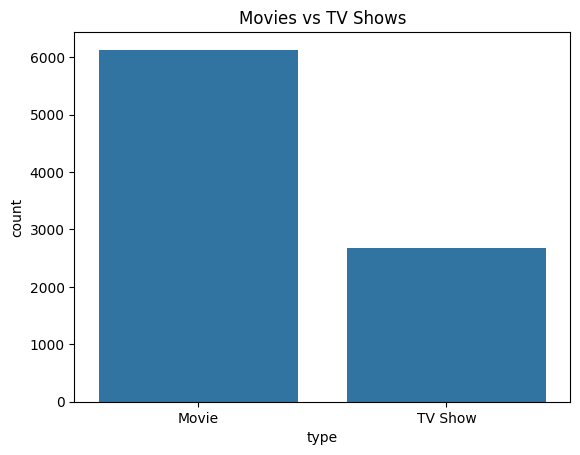

In [9]:
sns.countplot(
    x="type",
    data=df
)

plt.title("Movies vs TV Shows")

plt.show()

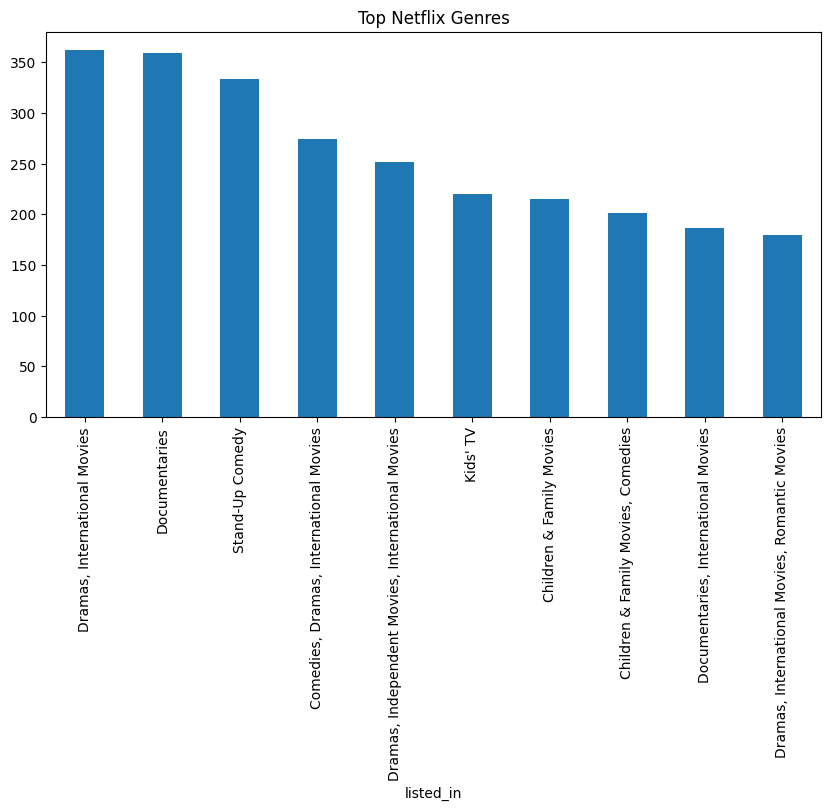

In [10]:
genre=df["listed_in"].value_counts().head(10)

genre.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Netflix Genres")

plt.show()

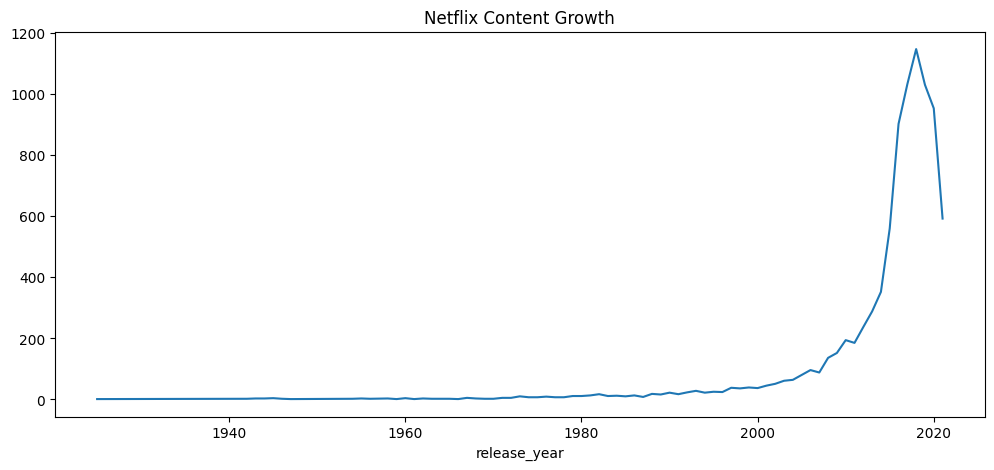

In [11]:
plt.figure(figsize=(12,5))

df["release_year"].value_counts().sort_index().plot()

plt.title("Netflix Content Growth")

plt.show()

In [12]:
movies=df[
["title","description","listed_in"]
]

In [13]:
movies["content"] = (
movies["description"]+" "+
movies["listed_in"]
)

/tmp/ipykernel_990/1154121593.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies["content"] = (


In [14]:
vectorizer=TfidfVectorizer(
stop_words="english"
)


matrix=vectorizer.fit_transform(
movies["content"]
)

In [15]:
similarity=cosine_similarity(matrix)

In [16]:
def recommend(movie):

    index = movies[
    movies["title"]==movie
    ].index[0]


    scores=list(
    enumerate(similarity[index])
    )


    scores=sorted(
    scores,
    key=lambda x:x[1],
    reverse=True
    )


    for i in scores[1:6]:
        print(
        movies.iloc[i[0]]["title"]
        )


recommend("The Matrix")

Arès
9
The Matrix Reloaded
She-Ra and the Princesses of Power
Cursed


In [17]:
similarity[0][1]

np.float64(0.0)

In [26]:
data = df.copy()

# fill missing values
data.fillna("Unknown", inplace=True)


# convert type
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data["type"] = le.fit_transform(data["type"])


# create useful features

data["duration_num"] = (
    data["duration"]
    .str.extract('(\d+)')
    .astype(float)
)


data["genre_count"] = (
    data["listed_in"]
    .apply(lambda x: len(str(x).split(",")))
)


data.head()

<>:19: SyntaxWarning: invalid escape sequence '\d'
<>:19: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_990/4045432381.py:19: SyntaxWarning: invalid escape sequence '\d'
  .str.extract('(\d+)')


,Column1,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_num,genre_count
0,s1,0,Dick Johnson Is Dead,Kirsten Johnson,UNKNOWN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,1
1,s2,1,Blood & Water,UNKNOWN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0,3
2,s3,1,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",UNKNOWN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1.0,3
3,s4,1,Jailbirds New Orleans,UNKNOWN,UNKNOWN,UNKNOWN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1.0,2
4,s5,1,Kota Factory,UNKNOWN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2.0,3


In [27]:
X = data[
[
"release_year",
"duration_num",
"genre_count"
]
]

y = data["type"]

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)


model.fit(
    X_train,
    y_train
)


prediction=model.predict(X_test)


accuracy=accuracy_score(
    y_test,
    prediction
)


print("Accuracy:",accuracy*100,"%")

Accuracy: 99.94324631101021 %


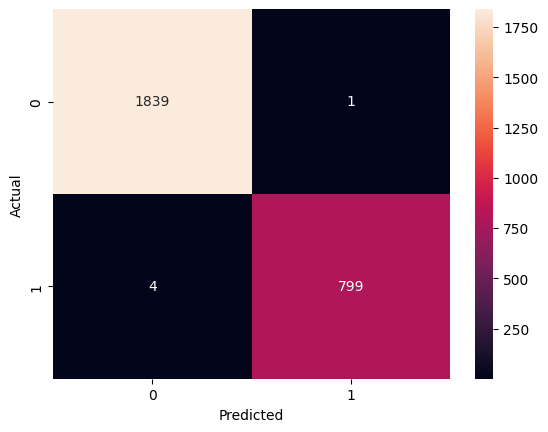

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(
    y_test,
    prediction
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()